In [1]:
from huggingface_hub import hf_hub_download
organization_dataset_id="hatemestinbejaia/STCALIR_Synthetic-Test-Collection"
hf_hub_download(repo_id=organization_dataset_id, filename="Raw Algerian Legal Texts Validated.csv", local_dir="./", repo_type="dataset")
import pandas
df = pandas.read_csv("Raw Algerian Legal Texts Validated.csv")
print(df["doc_id"].is_unique)
print(df.head(1))
print(len(df))

Raw Algerian Legal Texts Validated.csv:   0%|          | 0.00/165M [00:00<?, ?B/s]

True
   index  Numero  Journal  Nature  F_Page  A_Page  F_Publication  \
0      3       4        1       3     2.0     2.0       19750103   

   A_Publication  F_Signature  A_Signature  \
0     13941220.0   19741206.0   13941122.0   

                                          F_Sommaire  \
0  Sommaire Portant ratification de l'accord comm...   

                                          A_Sommaire  \
0  ملخص يتضمن المصادقة على الاتفاق التجاري المبرم...   

                                              FTexte  \
0  AU NOM DU PEUPLE, Le chef du Gouvernement, Pré...   

                                              ATexte  ATexte_Validated  \
0  باسم الشعب إن رئيس الحكومة، رئيس مجلس الوزراء،...               1.0   

   FTexte_Validated           doc_id  
0               1.0  19750103 01 004  
16148


count    16148.000000
mean       508.007927
std       1056.061687
min          0.000000
25%         38.000000
50%        197.000000
75%        470.250000
max      11691.000000
Name: word_count, dtype: float64


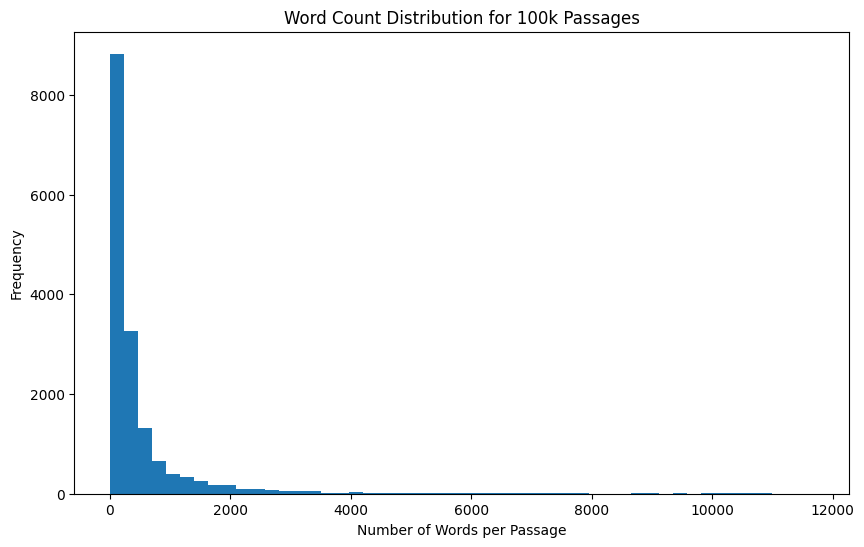

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# df['passage'] contains your 100k passages
# Replace with your column name
text_col = "ATexte"

# Compute word count for each passage
df["word_count"] = df[text_col].str.split().apply(len)

# Print basic statistics
print(df["word_count"].describe())

# Plot histogram (distribution)
plt.figure(figsize=(10, 6))
plt.hist(df["word_count"], bins=50)
plt.xlabel("Number of Words per Passage")
plt.ylabel("Frequency")
plt.title("Word Count Distribution for 100k Passages")
plt.show()


In [2]:
df = df[["doc_id", "ATexte",  'A_Sommaire']]
df.head(1)

,doc_id,ATexte,A_Sommaire
0,19750103 01 004,باسم الشعب إن رئيس الحكومة، رئيس مجلس الوزراء،...,ملخص يتضمن المصادقة على الاتفاق التجاري المبرم...


In [ ]:
import pandas as pd
import re
def split_text_into_passages(df, text_col="ATexte", doc_id_col="doc_id", sommaire_col="A_Sommaire", 
                             max_words=300, overlap=50):
    """
    Split long text in a DataFrame column into passages.
    
    Parameters:
    - df: Pandas DataFrame containing raw text
    - text_col: name of the column with text
    - doc_id_col: name of the column with document IDs
    - max_words: maximum words per passage (approx. token limit)
    - overlap: number of words to overlap between passages
    
    Returns:
    - df_passages: DataFrame with columns [doc_id, passage_id, text]
    """
    
    all_passages = []
    pattern = r'((?:ال)?مادة\s*[\d\u0621-\u064A]+\s*:)'
    for _, row in df.iterrows():
        text = str(row[text_col])
        doc_id = str(row[doc_id_col])
        sommaire = str(row[sommaire_col])
       
        parts = re.split(pattern, text)
        parts = [p.strip() for p in parts if p.strip()]
        # Now recombine "header + body"
        chunks = []
        i = 0
        while i < len(parts):
            if re.match(pattern, parts[i]):
                header = parts[i]
                body = parts[i+1] if i+1 < len(parts) else ""
                chunks.append(f"{header} {body}".strip())
                i += 2
            else:
                i += 1
        
        passage_idx = 1
        for j in chunks :
            passage_id = f"{doc_id}_p{passage_idx}"
            all_passages.append({
                "passage_id": passage_id,
                "text": j,
                "sommaire": sommaire
            })
            passage_idx += 1
        
    df_passages = pd.DataFrame(all_passages)
    return df_passages

# Example usage
# Suppose you have a DataFrame df with columns ['doc_id', 'ATexte']
# df = pd.read_csv("algerian_legal_raw.csv")  # example

df_passages = split_text_into_passages(df, text_col="ATexte", doc_id_col="doc_id", sommaire_col="A_Sommaire",
                                       max_words=384, overlap=50)


print(df_passages.head())
print(len(df_passages))

In [ ]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer, util

# ---------------- Settings ----------------
MAX_TOKENS = 350   # max tokens per sub-chunk
MIN_TOKENS = 40    # minimum tokens per sub-chunk
SIM_THRESHOLD = 0.35

# ---------------- Load embedding model ----------------
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# ---------------- Token counter ----------------
def tokenize_count(text):
    return len(text.split())

# ---------------- Semantic sub-chunker ----------------
def semantic_subchunks(article_text):
    # Split sentences
    sentences = re.split(r'(?<=[.؟!؛])\s+', article_text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Embed sentences
    emb = model.encode(sentences, convert_to_tensor=True)

    chunks = []
    current = [sentences[0]]

    for i in range(1, len(sentences)):
        sim = util.cos_sim(emb[i], emb[i-1]).item()
        merged = " ".join(current + [sentences[i]])

        if sim >= SIM_THRESHOLD and tokenize_count(merged) <= MAX_TOKENS:
            current.append(sentences[i])
        else:
            # merge small chunks
            if tokenize_count(" ".join(current)) < MIN_TOKENS:
                current.append(sentences[i])
            else:
                chunks.append(" ".join(current))
                current = [sentences[i]]

    chunks.append(" ".join(current))
    return chunks

def semantic_split_text_into_passages(df, text_col="text", passage_id_col ="passage_id", sommaire_col="sommaire", 
                             max_words=300, overlap=50):
    """
    Split long text in a DataFrame column into passages.
    
    Parameters:
    - df: Pandas DataFrame containing raw text
    - text_col: name of the column with text
    - doc_id_col: name of the column with document IDs
    - max_words: maximum words per passage (approx. token limit)
    - overlap: number of words to overlap between passages
    
    Returns:
    - df_passages: DataFrame with columns [doc_id, passage_id, text]
    """
    all_passages = []
    for _, row in df.iterrows():
        text = str(row[text_col])
        passage_id  = str(row[passage_id_col])
        sommaire = str(row[sommaire_col])
        if tokenize_count(text) < 400 : 
            all_passages.append({
                "passage_id": passage_id,
                "text": text,
                "sommaire": sommaire
            })
            continue 
        chunks = semantic_subchunks(text)
        semantic_idx =1
        for j in chunks :
            passage_id_new = f"{passage_id}_p{semantic_idx}"
            all_passages.append({
                "passage_id": passage_id_new,
                "text": j,
                "sommaire": sommaire
            })
            semantic_idx += 1
        
    df_passages = pd.DataFrame(all_passages)
    return df_passages

# Example usage
# Suppose you have a DataFrame df with columns ['doc_id', 'ATexte']
# df = pd.read_csv("algerian_legal_raw.csv")  # example

df_passages1 = semantic_split_text_into_passages(df_passages, text_col="text", passage_id_col="passage_id", sommaire_col="sommaire",
                                       max_words=384, overlap=50)

In [ ]:
df = df_passages1
df = df[df["text"].apply(lambda x: len(x.split()) <= 400)].reset_index(drop=True)

In [ ]:
x=0
import re
for i in range(len(df)):
    text = df["text"][i]  # your dataframe column
    if len(text.split())>400: 
        #print(i)
        x=x+1
        #break
print(x)
print(len(df))
print(df["text"][1])
df.head(1)

In [ ]:
!pip install arabic-reshaper python-bidi -q
!pip install ar_wordcloud -q
!pip install stop-words -q
!pip install matplotlib  -q

In [ ]:
import time
from tqdm.notebook import trange, tqdm
from sklearn.feature_extraction.text import CountVectorizer
# Takes in a document, returns the list of words
ArabertPreprocessor_text=[]
from stop_words import get_stop_words
stop_words = get_stop_words('arabic')  # convert to set for faster lookup
stop_words.extend(["على", "أن", "هذا", "إلى", "بعد", "مع", "في", "وفي", "رقم", "الموافق", "إذا", "الى"])
def tokenize_arb(doc):
    ArabertPreprocessor_text.append(doc.split())
    return doc.split()
def get_top_n_words(corpus, n=None):
    #vec = CountVectorizer(tokenizer= tokenize_arb, min_df=0.05).fit(corpus)
    vec = CountVectorizer(tokenizer=tokenize_arb, stop_words=stop_words, min_df=0.01).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in  vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]
common_words = get_top_n_words(df['text'])
#print(common_words)
#print(len(common_words))
#print(len(ArabertPreprocessor_text))

In [ ]:
print(len(common_words))
#print(len(ArabertPreprocessor_text))

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display
!pip install ar_wordcloud -q
!pip install stop-words -q
import matplotlib.pyplot as plt
from PIL import Image

from stop_words import get_stop_words
stop_words = get_stop_words('arabic')
s=""
for word in tqdm(stop_words):s=s+" "+word+ " "
reshaped_text = arabic_reshaper.reshape(s)
stop_words = get_display(reshaped_text)
stop_words = s.split()
stop_words.extend(["على", "أن", "هذا", "إلى", "بعد", "مع", "في", "وفي"])
stop_words = [w.strip() for w in stop_words]

from ar_wordcloud import ArabicWordCloud
# Remove all spaces from each word
c=""
for word, f  in tqdm(common_words):c=c+" "+word.replace(" ", "")+ " "
# ---------------- Reshape Arabic text ----------------
reshaped_text = arabic_reshaper.reshape(c)
bidi_text = get_display(reshaped_text)
awc = ArabicWordCloud(width = 800, height = 800, background_color ='white',min_font_size = 10, stopwords=stop_words)
wc = awc.from_text(bidi_text)
wc.to_file('wc.png')
im = Image.open("wc.png")
# plot the WordCloud image                      
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(im)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [ ]:
df["text_with_summary"] = df["text"] + " " + df["sommaire"]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# df['passage'] contains your 100k passages
# Replace with your column name
text_col = "text_with_summary"

# Compute word count for each passage
df["word_count"] = df[text_col].str.split().apply(len)

# Print basic statistics
print(df["word_count"].describe())

# Plot histogram (distribution)
plt.figure(figsize=(10, 6))
plt.hist(df["word_count"], bins=50)
plt.xlabel("Number of Words per Passage")
plt.ylabel("Frequency")
plt.title("Word Count Distribution for 100k Passages")
plt.show()


In [ ]:
df.to_csv('Corpus Algerian Legal Texts.csv', index=False, encoding='utf8')
organization_dataset_id="hatemestinbejaia/STCALIR_Synthetic-Test-Collection"
#organization_dataset_id="your huggingface reposit"
!pip install -U datasets huggingface-hub -q
from huggingface_hub import login
access_token = "your huggingface apikey"
#access_token = "your access token"
# This saves your token for use by Transformers, pipelines, etc.
login(token=access_token)

from huggingface_hub import HfApi
api = HfApi()
api.upload_file(
    path_or_fileobj="Corpus Algerian Legal Texts.csv",
    path_in_repo="Corpus Algerian Legal Texts.csv",
    repo_id=organization_dataset_id,
    repo_type="dataset",
)